# Task-Decoder Transformer Ablations: Static Context vs Early History

This notebook is a simpler interpretability check than SHAP. It retrains the same task-decoder Transformer architecture under two input ablations:

- **No static context**: demographic and parental-background vectors are zeroed out, so the model uses only age 20-29 outcome history.
- **No early history**: age 20-29 earnings/employment/marriage tokens are zeroed out, so the model uses only static demographic and parental-background context.

The goal is to compare validation/test performance against the original full-input task-decoder Transformer.

In [ ]:
from pathlib import Path
import json
import math
import random
import time
from itertools import product

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from scipy.stats import spearmanr
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, f1_score
from sklearn.linear_model import Lasso, LinearRegression, LogisticRegression, Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Device: cpu


In [ ]:
SEED = 1470

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

PANEL_PATH = Path('../data/processed/psid_panel.csv')
OUT_DIR = Path('../results/task_decoder_ablation_outputs')
OUT_DIR.mkdir(exist_ok=True)

INPUT_BINS = [(20, 21), (22, 23), (24, 25), (26, 27), (28, 29)]
TARGET_BINS = [(30, 31), (32, 33), (34, 35), (36, 37), (38, 39), (40, 41), (42, 43), (44, 45)]

def bin_label(lo, hi):
    return f'a{lo}' if lo == hi else f'a{lo}_{hi}'

input_bins = [bin_label(*b) for b in INPUT_BINS]
target_bins = [bin_label(*b) for b in TARGET_BINS]
print('Input bins:', input_bins)
print('Target bins:', target_bins)

Input bins: ['a20_21', 'a22_23', 'a24_25', 'a26_27', 'a28_29']
Target bins: ['a30_31', 'a32_33', 'a34_35', 'a36_37', 'a38_39', 'a40_41', 'a42_43', 'a44_45']


In [ ]:
panel = pd.read_csv(PANEL_PATH).sort_values(['ID', 'DEMO_AGE_GEN', 'YEAR']).reset_index(drop=True)

# Fresh exact 8:1:1 ID-level split.
ids_all = np.sort(panel['ID'].unique())
rng = np.random.default_rng(SEED)
shuffled = ids_all.copy()
rng.shuffle(shuffled)
n = len(shuffled)
n_train = int(round(0.8 * n))
n_val = int(round(0.1 * n))
split_map = pd.DataFrame({'ID': ids_all, 'split_new': 'test'})
split_map.loc[split_map['ID'].isin(shuffled[:n_train]), 'split_new'] = 'train'
split_map.loc[split_map['ID'].isin(shuffled[n_train:n_train+n_val]), 'split_new'] = 'val'
panel = panel.drop(columns=['split'], errors='ignore').merge(split_map, on='ID', how='left')
panel = panel.rename(columns={'split_new': 'split'})
print('IDs:', panel.ID.nunique())
print(panel[['ID', 'split']].drop_duplicates()['split'].value_counts())

IDs: 2585
split
train    2068
test      259
val       258
Name: count, dtype: int64


In [ ]:
STATIC_CONT = [
    'father_EARN_mean', 'father_FINC_mean', 'father_share_married', 'father_share_divorc',
    'father_EARN_sd', 'father_EDU_MAX', 'father_obs_cnt',
    'mother_EARN_mean', 'mother_FINC_mean', 'mother_share_married', 'mother_share_divorc',
    'mother_EARN_sd', 'mother_EDU_MAX', 'mother_obs_cnt',
]
STATIC_BINARY = ['PAR_BOTH_MISS']
STATIC_CAT = ['DEMO_SEX', 'RACE_ETH_MAJ_COL', 'CGEO_REGION', 'COHORT_BIN']

OUTCOMES = ['EARN_TOT_RDF', 'EMP_WORK', 'FAM_MARSTAT']

def latest_nonmissing(rows, col):
    vals = rows.loc[rows[col].notna()].sort_values(['DEMO_AGE_GEN', 'YEAR'])
    return np.nan if vals.empty else vals.iloc[-1][col]

def aggregate_bin(ego, lo, hi):
    rows = ego[(ego.DEMO_AGE_GEN >= lo) & (ego.DEMO_AGE_GEN <= hi)]
    earn_obs = rows['EARN_TOT_RDF'].notna()
    earn = rows.loc[earn_obs, 'EARN_TOT_RDF'].mean() if earn_obs.any() else np.nan
    emp = latest_nonmissing(rows, 'EMP_WORK')
    mar = latest_nonmissing(rows, 'FAM_MARSTAT')
    return {
        'earn': earn,
        'earn_mask': int(pd.notna(earn)),
        'emp': emp,
        'emp_mask': int(pd.notna(emp)),
        'mar': mar,
        'mar_mask': int(pd.notna(mar)),
    }

rows = []
for ego_id, ego in panel.groupby('ID', sort=True):
    rec = {'ID': ego_id, 'split': ego['split'].iloc[0]}
    for lo, hi in INPUT_BINS:
        label = bin_label(lo, hi)
        agg = aggregate_bin(ego, lo, hi)
        for k, v in agg.items():
            rec[f'in_{label}_{k}'] = v
    for lo, hi in TARGET_BINS:
        label = bin_label(lo, hi)
        agg = aggregate_bin(ego, lo, hi)
        for k, v in agg.items():
            rec[f'tgt_{label}_{k}'] = v
    rows.append(rec)

seq_df = pd.DataFrame(rows)
static_df = panel.sort_values(['ID', 'DEMO_AGE_GEN', 'YEAR']).groupby('ID', as_index=False)[['ID'] + STATIC_CONT + STATIC_BINARY + STATIC_CAT].first()
data = seq_df.merge(static_df, on='ID', how='left')
print(data.shape)
data.head()

(2585, 99)


,ID,split,in_a20_21_earn,in_a20_21_earn_mask,in_a20_21_emp,in_a20_21_emp_mask,in_a20_21_mar,in_a20_21_mar_mask,in_a22_23_earn,in_a22_23_earn_mask,...,mother_share_married,mother_share_divorc,mother_EARN_sd,mother_EDU_MAX,mother_obs_cnt,PAR_BOTH_MISS,DEMO_SEX,RACE_ETH_MAJ_COL,CGEO_REGION,COHORT_BIN
0,4007,val,NaN,0,NaN,0,NaN,0,NaN,0,...,0.222222,0.000000,0.736994,0.0,9.0,0,2,1.0,3.0,0
1,4031,train,NaN,0,NaN,0,NaN,0,0.000000,1,...,1.000000,0.000000,1.101707,1.0,9.0,0,2,1.0,3.0,2
2,4034,train,NaN,0,NaN,0,NaN,0,2.926694,1,...,0.333333,0.666667,2.104212,1.0,9.0,0,1,1.0,3.0,2
3,5003,train,2.393077,1,1.0,1,1.0,1,3.101122,1,...,0.444444,0.000000,0.822426,0.0,9.0,0,1,1.0,3.0,0
4,5004,train,NaN,0,NaN,0,NaN,0,NaN,0,...,0.777778,0.000000,0.832096,0.0,9.0,0,2,1.0,3.0,1


In [ ]:
train_mask = data['split'].eq('train')

# Category maps are fit on training data only. 0=missing, 1=unseen category.
def fit_cat_map(series):
    vals = sorted(series.dropna().astype(float).unique().tolist())
    return {str(v): i + 2 for i, v in enumerate(vals)}

def encode_with_map(series, mapping):
    def enc(v):
        if pd.isna(v):
            return 0
        return mapping.get(str(float(v)), 1)
    return series.map(enc).astype('int64')

emp_values = pd.concat([data.loc[train_mask, f'in_{b}_emp'] for b in input_bins] + [data.loc[train_mask, f'tgt_{b}_emp'] for b in target_bins])
mar_values = pd.concat([data.loc[train_mask, f'in_{b}_mar'] for b in input_bins] + [data.loc[train_mask, f'tgt_{b}_mar'] for b in target_bins])
emp_map = fit_cat_map(emp_values)
mar_map = fit_cat_map(mar_values)
static_cat_maps = {c: fit_cat_map(data.loc[train_mask, c]) for c in STATIC_CAT}

print('emp classes:', emp_map)
print('mar classes:', mar_map)
print('static cat maps:', {k: len(v) for k, v in static_cat_maps.items()})

emp classes: {'0.0': 2, '1.0': 3}
mar classes: {'1.0': 2, '2.0': 3, '3.0': 4, '4.0': 5, '5.0': 6}
static cat maps: {'DEMO_SEX': 2, 'RACE_ETH_MAJ_COL': 4, 'CGEO_REGION': 5, 'COHORT_BIN': 3}


In [ ]:
# Scale continuous inputs using train only.
earn_input_cols = [f'in_{b}_earn' for b in input_bins]
static_cont_cols = STATIC_CONT.copy()

earn_mean = data.loc[train_mask, earn_input_cols].stack().mean()
earn_std = data.loc[train_mask, earn_input_cols].stack().std(ddof=0)
earn_std = 1.0 if not np.isfinite(earn_std) or earn_std < 1e-8 else earn_std

static_stats = {}
for c in static_cont_cols:
    s = data.loc[train_mask, c].dropna().astype(float)
    mu = s.mean() if len(s) else 0.0
    sd = s.std(ddof=0) if len(s) else 1.0
    sd = 1.0 if not np.isfinite(sd) or sd < 1e-8 else sd
    static_stats[c] = (mu, sd)

ids = data['ID'].to_numpy(dtype=np.int64)
split = data['split'].astype(str).to_numpy()
N = len(data)
Tin = len(input_bins)
Tout = len(target_bins)

# History token continuous: scaled earnings plus masks for all three observed outcomes.
hist_cont = np.zeros((N, Tin, 4), dtype=np.float32)
hist_emp = np.zeros((N, Tin), dtype=np.int64)
hist_mar = np.zeros((N, Tin), dtype=np.int64)
for t, b in enumerate(input_bins):
    earn = ((data[f'in_{b}_earn'].astype(float) - earn_mean) / earn_std).fillna(0.0)
    hist_cont[:, t, 0] = earn.to_numpy(np.float32)
    hist_cont[:, t, 1] = data[f'in_{b}_earn_mask'].fillna(0).to_numpy(np.float32)
    hist_cont[:, t, 2] = data[f'in_{b}_emp_mask'].fillna(0).to_numpy(np.float32)
    hist_cont[:, t, 3] = data[f'in_{b}_mar_mask'].fillna(0).to_numpy(np.float32)
    hist_emp[:, t] = encode_with_map(data[f'in_{b}_emp'], emp_map).to_numpy()
    hist_mar[:, t] = encode_with_map(data[f'in_{b}_mar'], mar_map).to_numpy()

static_cont = np.zeros((N, len(static_cont_cols) + len(STATIC_BINARY)), dtype=np.float32)
for j, c in enumerate(static_cont_cols):
    mu, sd = static_stats[c]
    static_cont[:, j] = ((data[c].astype(float) - mu) / sd).fillna(0.0).to_numpy(np.float32)
for j, c in enumerate(STATIC_BINARY, start=len(static_cont_cols)):
    static_cont[:, j] = data[c].fillna(0).to_numpy(np.float32)

static_cat = np.stack([encode_with_map(data[c], static_cat_maps[c]).to_numpy() for c in STATIC_CAT], axis=1).astype(np.int64)

# Targets. Earnings stays on original signed-log scale. Categorical targets are class ids: -1 means missing.
y_earn = np.zeros((N, Tout), dtype=np.float32)
y_emp = np.full((N, Tout), -1, dtype=np.int64)
y_mar = np.full((N, Tout), -1, dtype=np.int64)
mask_earn = np.zeros((N, Tout), dtype=np.float32)
mask_emp = np.zeros((N, Tout), dtype=np.float32)
mask_mar = np.zeros((N, Tout), dtype=np.float32)
for t, b in enumerate(target_bins):
    earn = data[f'tgt_{b}_earn']
    y_earn[:, t] = earn.fillna(0.0).to_numpy(np.float32)
    mask_earn[:, t] = data[f'tgt_{b}_earn_mask'].fillna(0).to_numpy(np.float32)
    emp_enc = encode_with_map(data[f'tgt_{b}_emp'], emp_map).to_numpy()
    mar_enc = encode_with_map(data[f'tgt_{b}_mar'], mar_map).to_numpy()
    emp_m = data[f'tgt_{b}_emp_mask'].fillna(0).to_numpy(np.float32)
    mar_m = data[f'tgt_{b}_mar_mask'].fillna(0).to_numpy(np.float32)
    y_emp[:, t] = np.where(emp_m > 0, emp_enc, -1)
    y_mar[:, t] = np.where(mar_m > 0, mar_enc, -1)
    mask_emp[:, t] = emp_m
    mask_mar[:, t] = mar_m

print('hist_cont', hist_cont.shape, 'hist_emp', hist_emp.shape, 'static_cont', static_cont.shape)
print('target masks earn/emp/mar:', mask_earn.sum(axis=0).astype(int).tolist(), mask_emp.sum(axis=0).astype(int).tolist(), mask_mar.sum(axis=0).astype(int).tolist())

hist_cont (2585, 5, 4) hist_emp (2585, 5) static_cont (2585, 15)
target masks earn/emp/mar: [2506, 2522, 2541, 2513, 2517, 2519, 2549, 2493] [2510, 2526, 2541, 2516, 2515, 2520, 2549, 2489] [2511, 2526, 2543, 2518, 2519, 2524, 2550, 2494]


In [ ]:
class MultiOutcomeDataset(Dataset):
    def __init__(self, split_name):
        idx = np.where(split == split_name)[0]
        self.ids = torch.from_numpy(ids[idx])
        self.hist_cont = torch.from_numpy(hist_cont[idx])
        self.hist_emp = torch.from_numpy(hist_emp[idx])
        self.hist_mar = torch.from_numpy(hist_mar[idx])
        self.static_cont = torch.from_numpy(static_cont[idx])
        self.static_cat = torch.from_numpy(static_cat[idx])
        self.y_earn = torch.from_numpy(y_earn[idx])
        self.y_emp = torch.from_numpy(y_emp[idx])
        self.y_mar = torch.from_numpy(y_mar[idx])
        self.mask_earn = torch.from_numpy(mask_earn[idx])
        self.mask_emp = torch.from_numpy(mask_emp[idx])
        self.mask_mar = torch.from_numpy(mask_mar[idx])

    def __len__(self): return len(self.ids)

    def __getitem__(self, i):
        return {k: getattr(self, k)[i] for k in [
            'ids', 'hist_cont', 'hist_emp', 'hist_mar', 'static_cont', 'static_cat',
            'y_earn', 'y_emp', 'y_mar', 'mask_earn', 'mask_emp', 'mask_mar'
        ]}

def make_loader(split_name, batch_size=128, shuffle=False):
    return DataLoader(MultiOutcomeDataset(split_name), batch_size=batch_size, shuffle=shuffle)

print(len(MultiOutcomeDataset('train')), len(MultiOutcomeDataset('val')), len(MultiOutcomeDataset('test')))

2068 258 259


In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=64):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len, dtype=torch.float32).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div[:pe[:, 1::2].shape[1]])
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class StaticTokenizer(nn.Module):
    def __init__(self, n_cont, cat_vocab_sizes, d_model, cat_emb_dim=12):
        super().__init__()
        self.cont_feature = nn.Parameter(torch.randn(n_cont, d_model) * 0.02)
        self.cont_value = nn.Linear(1, d_model)
        self.cat_embs = nn.ModuleList([nn.Embedding(v, cat_emb_dim, padding_idx=0) for v in cat_vocab_sizes])
        self.cat_proj = nn.ModuleList([nn.Linear(cat_emb_dim, d_model) for _ in cat_vocab_sizes])
        self.cat_feature = nn.Parameter(torch.randn(len(cat_vocab_sizes), d_model) * 0.02)
        self.norm = nn.LayerNorm(d_model)
    def forward(self, cont, cat):
        toks = [self.cont_value(cont.unsqueeze(-1)) + self.cont_feature.unsqueeze(0)]
        for j, (emb, proj) in enumerate(zip(self.cat_embs, self.cat_proj)):
            toks.append((proj(emb(cat[:, j])) + self.cat_feature[j].unsqueeze(0)).unsqueeze(1))
        return self.norm(torch.cat(toks, dim=1))

def earn_to_scaled(x):
    return (x - float(earn_mean)) / float(earn_std)

def earn_from_scaled(x):
    return x * float(earn_std) + float(earn_mean)

def move_batch(batch):
    return {k: v.to(DEVICE) if torch.is_tensor(v) and k != 'ids' else v for k, v in batch.items()}

def masked_mse_scaled(pred_scaled, y_raw, mask):
    valid = mask > 0
    if not valid.any():
        return pred_scaled.sum() * 0.0
    y_scaled = earn_to_scaled(y_raw)
    return F.mse_loss(pred_scaled[valid], y_scaled[valid])

def masked_ce(logits, y, mask):
    valid = (mask > 0) & (y >= 0)
    if not valid.any():
        return logits.sum() * 0.0
    return F.cross_entropy(logits[valid], y[valid])

LOSS_WEIGHTS = {'earn': 1.0, 'emp': 0.5, 'mar': 0.5}

def multitask_loss(earn_scaled, emp, mar, batch):
    return (LOSS_WEIGHTS['earn'] * masked_mse_scaled(earn_scaled, batch['y_earn'], batch['mask_earn']) +
            LOSS_WEIGHTS['emp'] * masked_ce(emp, batch['y_emp'], batch['mask_emp']) +
            LOSS_WEIGHTS['mar'] * masked_ce(mar, batch['y_mar'], batch['mask_mar']))


## Task-Decoder Transformer

Shared history/static encoder with separate task-specific decoders for earnings, employment, and marriage. Hyperparameters are selected using validation earnings MSE; training loss is multi-task and masked.

In [ ]:
class CrossDecoderBlock(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.15, ff_mult=4):
        super().__init__()
        self.hist_cross = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.static_cross = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, ff_mult*d_model), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(ff_mult*d_model, d_model)
        )
        self.drop = nn.Dropout(dropout)

    def forward(self, q, hist_mem, static_mem):
        y, _ = self.hist_cross(q, hist_mem, hist_mem, need_weights=False)
        q = self.norm1(q + self.drop(y))
        y, _ = self.static_cross(q, static_mem, static_mem, need_weights=False)
        q = self.norm2(q + self.drop(y))
        q = self.norm3(q + self.drop(self.ff(q)))
        return q

class TaskSpecificDecoder(nn.Module):
    def __init__(self, d_model, n_heads, n_layers, dropout):
        super().__init__()
        self.query = nn.Parameter(torch.randn(Tout, d_model) * 0.02)
        self.blocks = nn.ModuleList([CrossDecoderBlock(d_model, n_heads, dropout=dropout) for _ in range(n_layers)])

    def forward(self, hist_mem, static_mem):
        q = self.query.unsqueeze(0).expand(hist_mem.size(0), -1, -1)
        for block in self.blocks:
            q = block(q, hist_mem, static_mem)
        return q

class MultiOutcomeTaskDecoderTransformer(nn.Module):
    def __init__(self, d_model=64, n_heads=4, n_hist_layers=1, n_task_layers=1, dropout=0.25,
                 emp_emb_dim=8, mar_emb_dim=8, static_cat_emb_dim=12):
        super().__init__()
        self.n_emp = max(emp_map.values()) + 1
        self.n_mar = max(mar_map.values()) + 1
        static_cat_vocab_sizes = [max(m.values()) + 1 for m in static_cat_maps.values()]
        self.hist_emp_emb = nn.Embedding(self.n_emp, emp_emb_dim, padding_idx=0)
        self.hist_mar_emb = nn.Embedding(self.n_mar, mar_emb_dim, padding_idx=0)
        self.hist_in = nn.Linear(4 + emp_emb_dim + mar_emb_dim, d_model)
        self.hist_pos = PositionalEncoding(d_model, max_len=16)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=4*d_model,
            dropout=dropout, batch_first=True, activation='gelu'
        )
        self.hist_encoder = nn.TransformerEncoder(enc_layer, num_layers=n_hist_layers)
        self.static_tok = StaticTokenizer(static_cont.shape[1], static_cat_vocab_sizes, d_model, static_cat_emb_dim)
        self.earn_dec = TaskSpecificDecoder(d_model, n_heads, n_task_layers, dropout)
        self.emp_dec = TaskSpecificDecoder(d_model, n_heads, n_task_layers, dropout)
        self.mar_dec = TaskSpecificDecoder(d_model, n_heads, n_task_layers, dropout)
        self.earn_head_scaled = nn.Linear(d_model, 1)
        self.emp_head = nn.Linear(d_model, self.n_emp)
        self.mar_head = nn.Linear(d_model, self.n_mar)

    def encode(self, hist_cont_b, hist_emp_b, hist_mar_b, static_cont_b, static_cat_b):
        h = torch.cat([hist_cont_b, self.hist_emp_emb(hist_emp_b), self.hist_mar_emb(hist_mar_b)], dim=-1)
        h = self.hist_pos(self.hist_in(h))
        hist_mem = self.hist_encoder(h)
        static_mem = self.static_tok(static_cont_b, static_cat_b)
        return hist_mem, static_mem

    def forward(self, hist_cont_b, hist_emp_b, hist_mar_b, static_cont_b, static_cat_b):
        hist_mem, static_mem = self.encode(hist_cont_b, hist_emp_b, hist_mar_b, static_cont_b, static_cat_b)
        earn_h = self.earn_dec(hist_mem, static_mem)
        emp_h = self.emp_dec(hist_mem, static_mem)
        mar_h = self.mar_dec(hist_mem, static_mem)
        return self.earn_head_scaled(earn_h).squeeze(-1), self.emp_head(emp_h), self.mar_head(mar_h)

def task_decoder_loss_fn(model, batch):
    earn_scaled, emp, mar = model(batch['hist_cont'], batch['hist_emp'], batch['hist_mar'], batch['static_cont'], batch['static_cat'])
    return multitask_loss(earn_scaled, emp, mar, batch)

def task_decoder_val_earn_mse(model, loader):
    model.eval()
    total, nobs = 0.0, 0
    with torch.no_grad():
        for batch in loader:
            batch = move_batch(batch)
            earn_scaled, _, _ = model(batch['hist_cont'], batch['hist_emp'], batch['hist_mar'], batch['static_cont'], batch['static_cat'])
            valid = batch['mask_earn'] > 0
            if valid.any():
                y_scaled = earn_to_scaled(batch['y_earn'])
                total += F.mse_loss(earn_scaled[valid], y_scaled[valid], reduction='sum').item()
                nobs += int(valid.sum().item())
    return total / max(nobs, 1)

def train_task_decoder_model(cfg, epochs=60, patience=7):
    set_seed(cfg.get('seed', SEED))
    model_cfg = {k:v for k,v in cfg.items() if k not in ['lr','weight_decay','batch_size','seed']}
    model = MultiOutcomeTaskDecoderTransformer(**model_cfg).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg['lr'], weight_decay=cfg['weight_decay'])
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    train_loader = make_loader('train', cfg['batch_size'], shuffle=True)
    val_loader = make_loader('val', cfg['batch_size'])
    best_val, bad, best_epoch = float('inf'), 0, 0
    best_state = {k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
    hist=[]
    for ep in range(epochs):
        model.train(); tr=0; ntr=0
        for batch in train_loader:
            batch = move_batch(batch)
            opt.zero_grad(); loss = task_decoder_loss_fn(model, batch); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); tr += loss.item()*batch['hist_cont'].size(0); ntr += batch['hist_cont'].size(0)
        sched.step(); tr/=max(ntr,1)
        val_mse = task_decoder_val_earn_mse(model, val_loader)
        hist.append({'epoch':ep, 'train_loss':tr, 'val_earn_mse':val_mse})
        if val_mse < best_val - 1e-5:
            best_val, best_epoch, bad = val_mse, ep, 0
            best_state = {k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
        else:
            bad += 1
        if ep % 5 == 0 or bad == 0:
            print(f'ep {ep:03d} train={tr:.4f} val_earn_mse={val_mse:.4f}{" *" if bad==0 else ""}')
        if bad >= patience: break
    model.load_state_dict(best_state)
    return model, best_val, best_epoch, pd.DataFrame(hist)


In [ ]:
def evaluate_task_decoder_transformer(model, split_name, batch_size=256):
    loader = make_loader(split_name, batch_size)
    model.eval()
    rows=[]; pred_rows=[]
    with torch.no_grad():
        for batch in loader:
            ids_b = batch['ids'].numpy()
            batch = move_batch(batch)
            earn_scaled, emp_logits, mar_logits = model(batch['hist_cont'], batch['hist_emp'], batch['hist_mar'], batch['static_cont'], batch['static_cat'])
            pred_earn = earn_from_scaled(earn_scaled).cpu().numpy()
            pred_emp = emp_logits.argmax(-1).cpu().numpy()
            pred_mar = mar_logits.argmax(-1).cpu().numpy()
            y_e = batch['y_earn'].cpu().numpy(); y_emp_b = batch['y_emp'].cpu().numpy(); y_mar_b = batch['y_mar'].cpu().numpy()
            m_e = batch['mask_earn'].cpu().numpy(); m_emp_b = batch['mask_emp'].cpu().numpy(); m_mar_b = batch['mask_mar'].cpu().numpy()
            for j,b in enumerate(target_bins):
                for i,ego_id in enumerate(ids_b):
                    pred_rows.append({'ID':int(ego_id),'split':split_name,'target_bin':b,
                                      'pred_earn':pred_earn[i,j],'true_earn':y_e[i,j],'mask_earn':m_e[i,j],
                                      'pred_emp':pred_emp[i,j],'true_emp':y_emp_b[i,j],'mask_emp':m_emp_b[i,j],
                                      'pred_mar':pred_mar[i,j],'true_mar':y_mar_b[i,j],'mask_mar':m_mar_b[i,j]})
    pred_df = pd.DataFrame(pred_rows)
    for b in target_bins:
        sub = pred_df[pred_df.target_bin.eq(b)]
        valid = sub.mask_earn > 0
        if valid.sum() > 1:
            y=sub.loc[valid,'true_earn']; p=sub.loc[valid,'pred_earn']; sp=spearmanr(y,p).correlation
            rows.append({'model':'TASK_DECODER_TRANSFORMER','split':split_name,'target_bin':b,'target':'earn','n':int(valid.sum()),
                         'rmse':float(np.sqrt(mean_squared_error(y,p))),'mae':float(mean_absolute_error(y,p)),
                         'r2':float(r2_score(y,p)),'spearman':float(sp) if np.isfinite(sp) else np.nan})
        for target, pred_col, true_col, mask_col in [('emp','pred_emp','true_emp','mask_emp'),('mar','pred_mar','true_mar','mask_mar')]:
            valid = sub[mask_col] > 0
            if valid.sum() > 1:
                rows.append({'model':'TASK_DECODER_TRANSFORMER','split':split_name,'target_bin':b,'target':target,'n':int(valid.sum()),
                             'accuracy':float(accuracy_score(sub.loc[valid,true_col], sub.loc[valid,pred_col])),
                             'f1_macro':float(f1_score(sub.loc[valid,true_col], sub.loc[valid,pred_col], average='macro', zero_division=0))})
    return pd.DataFrame(rows), pred_df


## Ablation Datasets

The architecture is unchanged. Only the input tensors are zeroed before they reach the model.

In [ ]:
class AblatedMultiOutcomeDataset(Dataset):
    def __init__(self, split_name, ablation='none'):
        idx = np.where(split == split_name)[0]
        self.ids = torch.from_numpy(ids[idx])
        self.hist_cont = torch.from_numpy(hist_cont[idx]).clone()
        self.hist_emp = torch.from_numpy(hist_emp[idx]).clone()
        self.hist_mar = torch.from_numpy(hist_mar[idx]).clone()
        self.static_cont = torch.from_numpy(static_cont[idx]).clone()
        self.static_cat = torch.from_numpy(static_cat[idx]).clone()
        self.y_earn = torch.from_numpy(y_earn[idx])
        self.y_emp = torch.from_numpy(y_emp[idx])
        self.y_mar = torch.from_numpy(y_mar[idx])
        self.mask_earn = torch.from_numpy(mask_earn[idx])
        self.mask_emp = torch.from_numpy(mask_emp[idx])
        self.mask_mar = torch.from_numpy(mask_mar[idx])

        if ablation == 'no_static':
            self.static_cont.zero_()
            self.static_cat.zero_()
        elif ablation == 'no_history':
            self.hist_cont.zero_()
            self.hist_emp.zero_()
            self.hist_mar.zero_()
        elif ablation != 'none':
            raise ValueError(f'Unknown ablation: {ablation}')

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, i):
        return {k: getattr(self, k)[i] for k in [
            'ids', 'hist_cont', 'hist_emp', 'hist_mar', 'static_cont', 'static_cat',
            'y_earn', 'y_emp', 'y_mar', 'mask_earn', 'mask_emp', 'mask_mar'
        ]}

def make_ablation_loader(split_name, ablation='none', batch_size=128, shuffle=False):
    return DataLoader(AblatedMultiOutcomeDataset(split_name, ablation), batch_size=batch_size, shuffle=shuffle)

for ablation in ['none', 'no_static', 'no_history']:
    batch = next(iter(make_ablation_loader('train', ablation=ablation, batch_size=4)))
    print(ablation, batch['hist_cont'].abs().sum().item(), batch['static_cont'].abs().sum().item())

none 65.45513916015625 35.9244270324707
no_static 65.45513916015625 0.0
no_history 0.0 35.9244270324707


## Train Ablated Models

Hyperparameters are taken from the original task-decoder search result if available. Otherwise a compact fallback is used.

In [ ]:
ORIGINAL_OUT_DIR = Path('../results/multioutcome_transformer_lasso_outputs')
ORIGINAL_SEARCH_PATH = ORIGINAL_OUT_DIR / 'task_decoder_transformer_search.csv'

fallback_cfg = {
    'd_model': 64,
    'n_heads': 4,
    'n_hist_layers': 1,
    'n_task_layers': 1,
    'dropout': 0.25,
    'lr': 1e-3,
    'weight_decay': 1e-4,
    'batch_size': 128,
    'seed': SEED,
}

if ORIGINAL_SEARCH_PATH.exists():
    original_search = pd.read_csv(ORIGINAL_SEARCH_PATH).sort_values('val_earn_mse')
    best_row = original_search.iloc[0]
    base_cfg = fallback_cfg.copy()
    for k in ['d_model', 'n_heads', 'n_hist_layers', 'n_task_layers', 'batch_size', 'seed']:
        base_cfg[k] = int(best_row[k])
    for k in ['dropout', 'lr', 'weight_decay']:
        base_cfg[k] = float(best_row[k])
    print('Using original task-decoder best hyperparameters:')
else:
    base_cfg = fallback_cfg.copy()
    print('Original search file not found; using fallback hyperparameters:')
print(base_cfg)

Using original task-decoder best hyperparameters:
{'d_model': 64, 'n_heads': 4, 'n_hist_layers': 1, 'n_task_layers': 1, 'dropout': 0.1, 'lr': 0.001, 'weight_decay': 0.001, 'batch_size': 128, 'seed': 1470}


In [ ]:
def task_decoder_loss_fn_ablation(model, batch):
    earn_scaled, emp, mar = model(batch['hist_cont'], batch['hist_emp'], batch['hist_mar'], batch['static_cont'], batch['static_cat'])
    return multitask_loss(earn_scaled, emp, mar, batch)

def task_decoder_val_earn_mse_ablation(model, loader):
    model.eval()
    total, nobs = 0.0, 0
    with torch.no_grad():
        for batch in loader:
            batch = move_batch(batch)
            earn_scaled, _, _ = model(batch['hist_cont'], batch['hist_emp'], batch['hist_mar'], batch['static_cont'], batch['static_cat'])
            valid = batch['mask_earn'] > 0
            if valid.any():
                y_scaled = earn_to_scaled(batch['y_earn'])
                total += F.mse_loss(earn_scaled[valid], y_scaled[valid], reduction='sum').item()
                nobs += int(valid.sum().item())
    return total / max(nobs, 1)

def train_task_decoder_ablation(cfg, ablation, epochs=60, patience=7):
    set_seed(cfg.get('seed', SEED))
    model_cfg = {k:v for k,v in cfg.items() if k not in ['lr','weight_decay','batch_size','seed']}
    model = MultiOutcomeTaskDecoderTransformer(**model_cfg).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg['lr'], weight_decay=cfg['weight_decay'])
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    train_loader = make_ablation_loader('train', ablation=ablation, batch_size=cfg['batch_size'], shuffle=True)
    val_loader = make_ablation_loader('val', ablation=ablation, batch_size=cfg['batch_size'])
    best_val, bad, best_epoch = float('inf'), 0, 0
    best_state = {k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
    hist=[]
    for ep in range(epochs):
        model.train(); tr=0.0; ntr=0
        for batch in train_loader:
            batch = move_batch(batch)
            opt.zero_grad()
            loss = task_decoder_loss_fn_ablation(model, batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); tr += loss.item()*batch['hist_cont'].size(0); ntr += batch['hist_cont'].size(0)
        sched.step(); tr /= max(ntr, 1)
        val_mse = task_decoder_val_earn_mse_ablation(model, val_loader)
        hist.append({'epoch': ep, 'train_loss': tr, 'val_earn_mse': val_mse, 'ablation': ablation})
        print(f'{ablation} epoch {ep:03d} train {tr:.4f} val_earn_mse {val_mse:.4f}')
        if val_mse < best_val - 1e-5:
            best_val, bad, best_epoch = val_mse, 0, ep
            best_state = {k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
        else:
            bad += 1
            if bad >= patience:
                break
    model.load_state_dict(best_state)
    return model, best_val, best_epoch, pd.DataFrame(hist)

In [ ]:
def evaluate_task_decoder_ablation(model, split_name, ablation, model_name, batch_size=256):
    loader = make_ablation_loader(split_name, ablation=ablation, batch_size=batch_size)
    model.eval()
    rows=[]; pred_rows=[]
    with torch.no_grad():
        for batch in loader:
            ids_b = batch['ids'].numpy()
            batch = move_batch(batch)
            earn_scaled, emp_logits, mar_logits = model(batch['hist_cont'], batch['hist_emp'], batch['hist_mar'], batch['static_cont'], batch['static_cat'])
            pred_earn = earn_from_scaled(earn_scaled).cpu().numpy()
            pred_emp = emp_logits.argmax(-1).cpu().numpy()
            pred_mar = mar_logits.argmax(-1).cpu().numpy()
            y_e = batch['y_earn'].cpu().numpy(); y_emp_b = batch['y_emp'].cpu().numpy(); y_mar_b = batch['y_mar'].cpu().numpy()
            m_e = batch['mask_earn'].cpu().numpy(); m_emp_b = batch['mask_emp'].cpu().numpy(); m_mar_b = batch['mask_mar'].cpu().numpy()
            for j,b in enumerate(target_bins):
                for i,ego_id in enumerate(ids_b):
                    pred_rows.append({'ID':int(ego_id),'split':split_name,'target_bin':b,'ablation':ablation,
                                      'pred_earn':pred_earn[i,j],'true_earn':y_e[i,j],'mask_earn':m_e[i,j],
                                      'pred_emp':pred_emp[i,j],'true_emp':y_emp_b[i,j],'mask_emp':m_emp_b[i,j],
                                      'pred_mar':pred_mar[i,j],'true_mar':y_mar_b[i,j],'mask_mar':m_mar_b[i,j]})
    pred_df = pd.DataFrame(pred_rows)
    for b in target_bins:
        sub = pred_df[pred_df.target_bin.eq(b)]
        valid = sub.mask_earn > 0
        if valid.sum() > 1:
            y=sub.loc[valid,'true_earn']; p=sub.loc[valid,'pred_earn']; sp=spearmanr(y,p).correlation
            rows.append({'model':model_name,'split':split_name,'target_bin':b,'target':'earn','ablation':ablation,'n':int(valid.sum()),
                         'rmse':float(np.sqrt(mean_squared_error(y,p))),'mae':float(mean_absolute_error(y,p)),
                         'r2':float(r2_score(y,p)),'spearman':float(sp) if np.isfinite(sp) else np.nan})
        for target, pred_col, true_col, mask_col in [('emp','pred_emp','true_emp','mask_emp'),('mar','pred_mar','true_mar','mask_mar')]:
            valid = sub[mask_col] > 0
            if valid.sum() > 1:
                rows.append({'model':model_name,'split':split_name,'target_bin':b,'target':target,'ablation':ablation,'n':int(valid.sum()),
                             'accuracy':float(accuracy_score(sub.loc[valid,true_col], sub.loc[valid,pred_col])),
                             'f1_macro':float(f1_score(sub.loc[valid,true_col], sub.loc[valid,pred_col], average='macro', zero_division=0))})
    return pd.DataFrame(rows), pred_df

In [ ]:
ablation_runs = {}
for ablation, model_name in [
    ('no_static', 'TASK_DECODER_NO_STATIC'),
    ('no_history', 'TASK_DECODER_NO_EARLY_HISTORY'),
]:
    model, val_mse, best_epoch, history = train_task_decoder_ablation(base_cfg, ablation=ablation, epochs=60, patience=7)
    ablation_runs[ablation] = {'model': model, 'val_earn_mse': val_mse, 'best_epoch': best_epoch, 'history': history, 'model_name': model_name}
    torch.save({'state_dict': model.state_dict(), 'cfg': base_cfg, 'ablation': ablation, 'target_bins': target_bins}, OUT_DIR / f'best_{ablation}_task_decoder_transformer.pt')
    history.to_csv(OUT_DIR / f'{ablation}_task_decoder_history.csv', index=False)

pd.DataFrame([
    {'ablation': k, 'model': v['model_name'], 'val_earn_mse': v['val_earn_mse'], 'best_epoch': v['best_epoch'], **base_cfg}
    for k, v in ablation_runs.items()
]).to_csv(OUT_DIR / 'task_decoder_ablation_search.csv', index=False)

pd.DataFrame([
    {'ablation': k, 'model': v['model_name'], 'val_earn_mse': v['val_earn_mse'], 'best_epoch': v['best_epoch']}
    for k, v in ablation_runs.items()
])

no_static epoch 000 train 1.9789 val_earn_mse 1.0274
no_static epoch 001 train 1.5601 val_earn_mse 0.9707
no_static epoch 002 train 1.4741 val_earn_mse 0.9871
no_static epoch 003 train 1.4382 val_earn_mse 1.0381
no_static epoch 004 train 1.4363 val_earn_mse 0.9512
no_static epoch 005 train 1.4277 val_earn_mse 0.9575
no_static epoch 006 train 1.4043 val_earn_mse 0.9481
no_static epoch 007 train 1.4070 val_earn_mse 0.9466
no_static epoch 008 train 1.3893 val_earn_mse 0.9339
no_static epoch 009 train 1.3756 val_earn_mse 0.9910
no_static epoch 010 train 1.3747 val_earn_mse 0.9684
no_static epoch 011 train 1.3736 val_earn_mse 0.9454
no_static epoch 012 train 1.3717 val_earn_mse 0.9526
no_static epoch 013 train 1.3692 val_earn_mse 0.9590
no_static epoch 014 train 1.3684 val_earn_mse 0.9397
no_static epoch 015 train 1.3623 val_earn_mse 0.9219
no_static epoch 016 train 1.3678 val_earn_mse 0.9272
no_static epoch 017 train 1.3612 val_earn_mse 0.9729
no_static epoch 018 train 1.3645 val_earn_mse 

,ablation,model,val_earn_mse,best_epoch
0,no_static,TASK_DECODER_NO_STATIC,0.921896,15
1,no_history,TASK_DECODER_NO_EARLY_HISTORY,1.127708,6


## Evaluate Ablations

In [ ]:
metric_frames = []
pred_frames = []
for ablation, run in ablation_runs.items():
    for split_name in ['val', 'test']:
        m, p = evaluate_task_decoder_ablation(run['model'], split_name, ablation, run['model_name'])
        metric_frames.append(m)
        pred_frames.append(p)

ablation_metrics = pd.concat(metric_frames, ignore_index=True)
ablation_preds = pd.concat(pred_frames, ignore_index=True)
ablation_metrics.to_csv(OUT_DIR / 'task_decoder_ablation_metrics.csv', index=False)
ablation_preds.to_csv(OUT_DIR / 'task_decoder_ablation_predictions.csv', index=False)
ablation_metrics.head()

,model,split,target_bin,target,ablation,n,rmse,mae,r2,spearman,accuracy,f1_macro
0,TASK_DECODER_NO_STATIC,val,a30_31,earn,no_static,248,0.925598,0.639982,0.528456,0.747815,NaN,NaN
1,TASK_DECODER_NO_STATIC,val,a30_31,emp,no_static,250,NaN,NaN,NaN,NaN,0.836000,0.703851
2,TASK_DECODER_NO_STATIC,val,a30_31,mar,no_static,250,NaN,NaN,NaN,NaN,0.868000,0.687123
3,TASK_DECODER_NO_STATIC,val,a32_33,earn,no_static,251,1.034952,0.779101,0.366396,0.644053,NaN,NaN
4,TASK_DECODER_NO_STATIC,val,a32_33,emp,no_static,251,NaN,NaN,NaN,NaN,0.848606,0.684590


In [ ]:
# Optional comparison to the original full-input task-decoder metrics.
orig_path = Path('../results/multioutcome_transformer_lasso_outputs/task_decoder_transformer_metrics.csv')
if orig_path.exists():
    orig = pd.read_csv(orig_path)
    orig['ablation'] = 'full_inputs'
    compare = pd.concat([orig, ablation_metrics], ignore_index=True, sort=False)
else:
    compare = ablation_metrics.copy()

summary = compare.groupby(['model', 'ablation', 'split', 'target'], as_index=False).agg(
    avg_r2=('r2', 'mean'),
    avg_accuracy=('accuracy', 'mean'),
    avg_f1_macro=('f1_macro', 'mean'),
)
summary.to_csv(OUT_DIR / 'task_decoder_ablation_summary.csv', index=False)
summary

,model,ablation,split,target,avg_r2,avg_accuracy,avg_f1_macro
0,TASK_DECODER_NO_EARLY_HISTORY,no_history,test,earn,0.143961,NaN,NaN
1,TASK_DECODER_NO_EARLY_HISTORY,no_history,test,emp,NaN,0.816933,0.449553
2,TASK_DECODER_NO_EARLY_HISTORY,no_history,test,mar,NaN,0.703607,0.285707
3,TASK_DECODER_NO_EARLY_HISTORY,no_history,val,earn,0.098161,NaN,NaN
4,TASK_DECODER_NO_EARLY_HISTORY,no_history,val,emp,NaN,0.808903,0.447121
5,TASK_DECODER_NO_EARLY_HISTORY,no_history,val,mar,NaN,0.701632,0.230118
6,TASK_DECODER_NO_STATIC,no_static,test,earn,0.336675,NaN,NaN
7,TASK_DECODER_NO_STATIC,no_static,test,emp,NaN,0.821467,0.586211
8,TASK_DECODER_NO_STATIC,no_static,test,mar,NaN,0.746288,0.424547
9,TASK_DECODER_NO_STATIC,no_static,val,earn,0.266614,NaN,NaN


## Test-Set Earnings Ablation Graph

This plot compares average test earnings R² for the full model, early-history-only model, and static-context-only model.

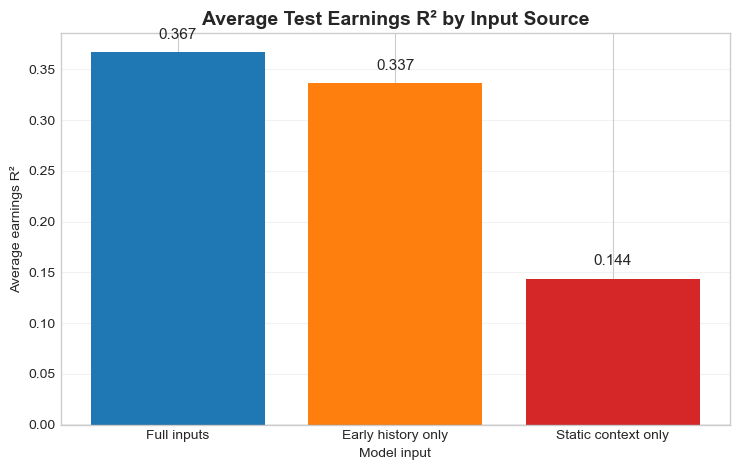

saved: task_decoder_ablation_outputs/plots/test_earnings_ablation_average_r2.png


,display_model,avg_r2
0,Full inputs,0.366971
1,Early history only,0.336675
2,Static context only,0.143961


In [ ]:
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
PLOT_DIR = OUT_DIR / 'plots'
PLOT_DIR.mkdir(exist_ok=True)

plot_metrics = compare[(compare['split'].eq('test')) & (compare['target'].eq('earn'))].copy()
plot_metrics['display_model'] = plot_metrics['ablation'].map({
    'full_inputs': 'Full inputs',
    'no_static': 'Early history only',
    'no_history': 'Static context only',
}).fillna(plot_metrics['ablation'])

MODEL_ORDER = ['Full inputs', 'Early history only', 'Static context only']
COLORS = {
    'Full inputs': '#1f77b4',
    'Early history only': '#ff7f0e',
    'Static context only': '#d62728',
}

avg_earn = plot_metrics.groupby('display_model', as_index=False).agg(avg_r2=('r2', 'mean'))
avg_earn['display_model'] = pd.Categorical(avg_earn['display_model'], categories=MODEL_ORDER, ordered=True)
avg_earn = avg_earn.sort_values('display_model').reset_index(drop=True)
avg_earn.to_csv(OUT_DIR / 'test_earnings_ablation_average_r2.csv', index=False)

fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.bar(
    avg_earn['display_model'].astype(str),
    avg_earn['avg_r2'],
    color=[COLORS[m] for m in avg_earn['display_model'].astype(str)],
)
ax.axhline(0, color='black', linewidth=1, alpha=0.35)
ax.set_title('Average Test Earnings R² by Input Source', fontsize=14, weight='bold')
ax.set_xlabel('Model input')
ax.set_ylabel('Average earnings R²')
ax.grid(True, axis='y', alpha=0.25)
for i, v in enumerate(avg_earn['avg_r2']):
    if pd.notna(v):
        ax.text(i, v + (0.01 if v >= 0 else -0.03), f'{v:.3f}', ha='center', va='bottom' if v >= 0 else 'top', fontsize=11)
fig.tight_layout()
path = PLOT_DIR / 'test_earnings_ablation_average_r2.png'
fig.savefig(path, dpi=300, bbox_inches='tight')
plt.show()
print('saved:', path)

avg_earn